# Proyecto de Analítica Predictiva: **Análisis exploratorio de datos del IDEAM con enfoque en pronósticos del clima y su afectación sobre los cultivos del departamento de Antioquia**
### Autor: Grupo N - Sala 14
### Integrantes: Luisa Franco, Andres Martinez, Alexander Velez y Wilson Castañeda.
**Descripción:** Este cuaderno implementa un flujo completo de ciencia de datos, desde la conexión a una base de datos **MySQL** en la nube **(Railway)** hasta la creación de un modelo predictivo basado en Machine Learning.

---
## 1. Configuración del Entorno
Instalamos las librerías necesarias para la conexión con la base de datos y la manipulación de datos.

In [ ]:
!pip install pymysql sqlalchemy

## 2. Conexión a la Base de Datos (Railway)
En esta sección establecemos el túnel de comunicación con el servidor **MySQL**.

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# Credenciales de acceso
USER = 'root'
PASSWORD = 'NcFVFxnmCZReanbgvkWqUlVfKLRyZZiT'
HOST = 'hopper.proxy.rlwy.net'
PORT = '16653'
DATABASE = 'proyecto_agricola'

# Configuración del motor de conexión
connection_string = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
engine = create_engine(connection_string)

print("✅ Conexión establecida exitosamente.")

✅ Conexión establecida exitosamente.


## 3. Extracción y Limpieza de Datos (ETL)
Extraemos la información histórica de la tabla de **Temperaturas** de la base de datos **Proyecto Agricola** para transformarla en un DataFrame de Pandas.
Realizamos una limpieza inicial para asegurar la calidad de los datos (manejo de valores nulos).

In [ ]:
# Consulta SQL
query = "SELECT Fecha_nueva as Fecha, Parametro, Municipio, Municipio_ID, Valor_num as Temperatura FROM temperaturas order by fecha_nueva"

# Carga de datos
df = pd.read_sql(query, engine)

# Limpieza básica
df = df.dropna()

# Visualización de las primeras 5 filas
df.head()

,Fecha,Parametro,Municipio,Municipio_ID,Temperatura
0,2000-01-01,Temperatura máxima diaria,Alejandría,5,23.6
1,2000-01-01,Temperatura mínima diaria,Urrao,3,14.6
2,2000-01-01,Temperatura máxima diaria,Urrao,3,21.6
3,2000-01-01,Temperatura mínima diaria,Cañasgordas,2,16.0
4,2000-01-01,Temperatura mínima diaria,Alejandría,5,13.2


## 4. Análisis Exploratorio de Datos (EDA) y Transformación de Datos
Antes de construir el modelo, visualizamos la distribución de los datos y las correlaciones entre las variables climáticas de **Temperatura Minima y Maxima**.

Dado que los datos vienen en formato de lista de parámetros, realizaremos un **Pivot** para organizar las temperaturas máximas y mínimas como columnas independientes. Esto es esencial para que el modelo pueda correlacionar ambos valores por día y municipio.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pivotar datos: Ahora incluimos 'Municipio_ID' en el índice
df_pivot = df.pivot_table(
    index=['Fecha', 'Municipio', 'Municipio_ID'],
    columns='Parametro',
    values='Temperatura'
).reset_index()

# Renombrar columnas para facilitar el manejo
df_pivot.columns.name = None
df_pivot = df_pivot.rename(columns={
    'Temperatura máxima diaria': 'temp_max',
    'Temperatura mínima diaria': 'temp_min'
})

# Manejo de valores nulos resultantes del pivot (esencial)
df_final = df_pivot.dropna()

# Mostrar nueva estructura normalizada
print(f"Número de registros tras limpieza: {df_final.shape[0]}")
df_final.head()

Número de registros tras limpieza: 28544


,Fecha,Municipio,Municipio_ID,temp_max,temp_min
0,2000-01-01,Alejandría,5,23.6,13.2
1,2000-01-01,Cañasgordas,2,27.2,16.0
2,2000-01-01,Urrao,3,21.6,14.6
3,2000-01-02,Alejandría,5,24.0,14.2
4,2000-01-02,Cañasgordas,2,24.8,16.6


### 4.1. Análisis Visual de la Distribución Térmica por Municipio
Antes de proceder al modelado, visualizamos cómo se distribuyen las temperaturas máximas y mínimas en los municipios seleccionados. Esto nos permite identificar variaciones climáticas regionales (microclimas) que el modelo deberá aprender.

/tmp/ipykernel_931/112558217.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Municipio', y='temp_max', palette='viridis')


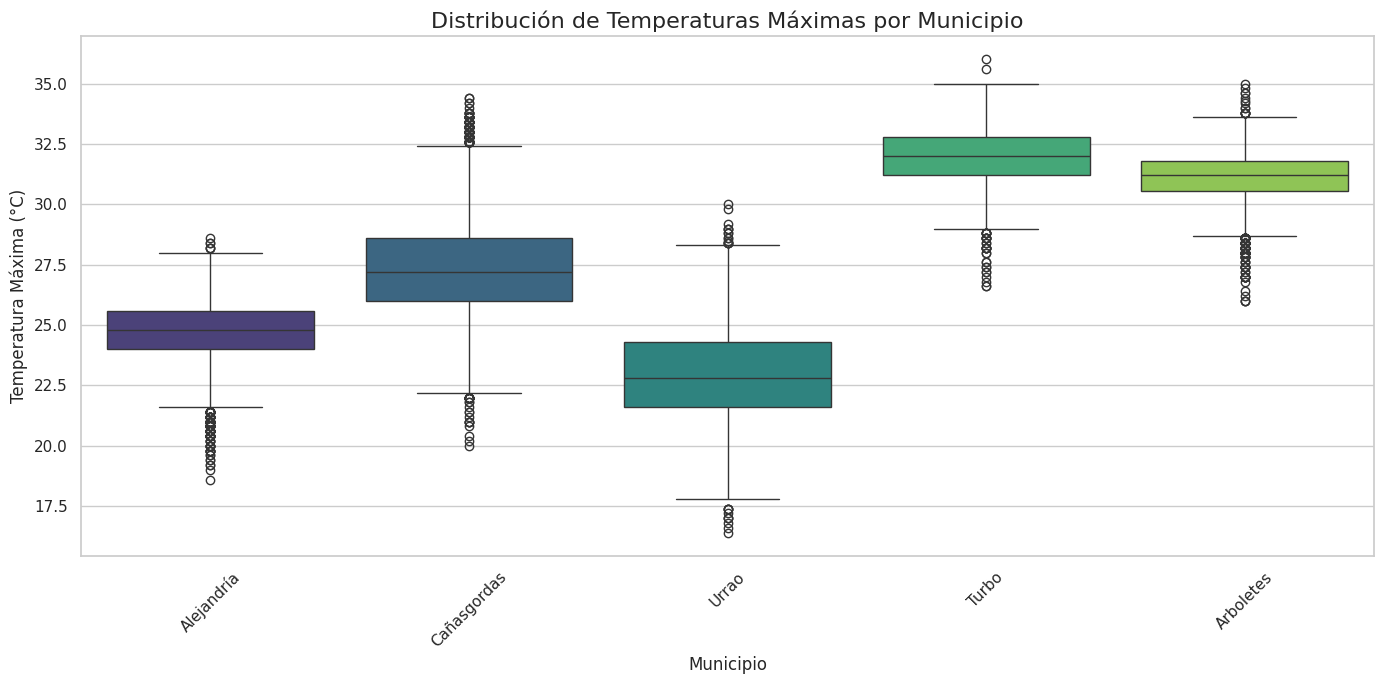

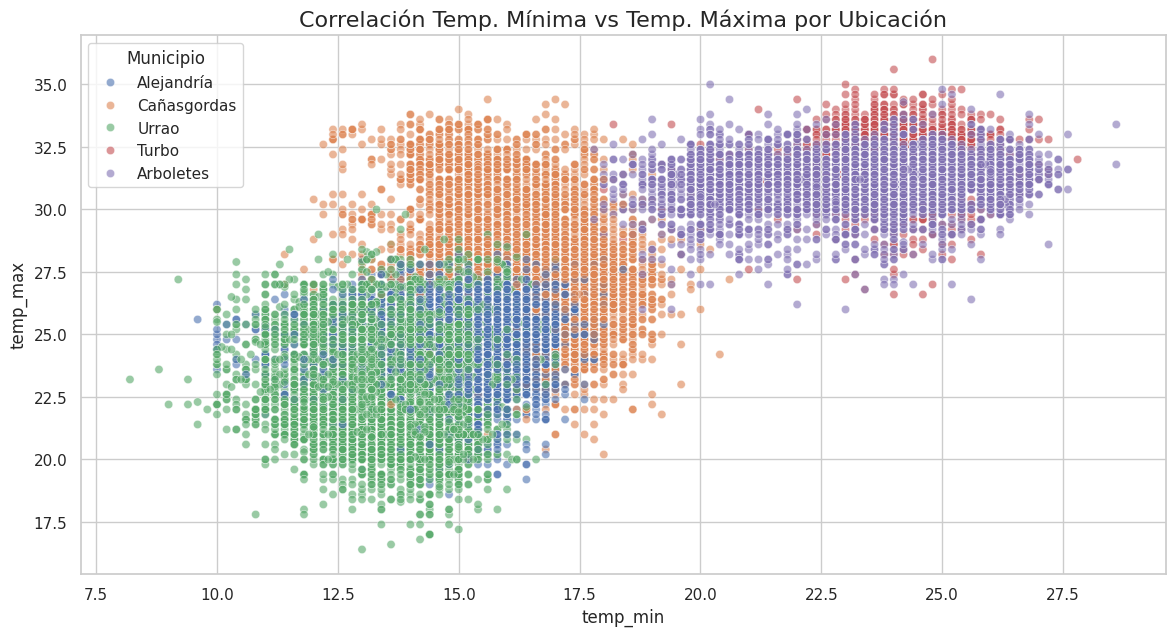

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Creamos un gráfico de caja (Boxplot) para ver la distribución de Temp Máxima por Municipio
# El Boxplot es ideal para ver promedios, valores máximos y posibles anomalías
sns.boxplot(data=df_final, x='Municipio', y='temp_max', palette='viridis')

plt.title('Distribución de Temperaturas Máximas por Municipio', fontsize=16)
plt.xlabel('Municipio', fontsize=12)
plt.ylabel('Temperatura Máxima (°C)', fontsize=12)
plt.xticks(rotation=45) # Rotamos los nombres para que se lean bien

plt.tight_layout()
plt.show()

# Gráfico adicional: Relación entre Mínima y Máxima coloreado por Municipio
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df_final, x='temp_min', y='temp_max', hue='Municipio', alpha=0.6)
plt.title('Correlación Temp. Mínima vs Temp. Máxima por Ubicación', fontsize=16)
plt.show()

## 5. Entrenamiento del Modelo Predictivo (Random Forest)

Entrenaremos el modelo usando la **Temperatura Mínima**, el **Mes**, el **Día** y, crucialmente, el **Municipio_ID**. Esto permitirá que el modelo aprenda matemáticamente la influencia de cada ubicación específica.

> **Nota:** Convertiremos la fecha en valores numéricos (Mes y Día) para que el modelo entienda la estacionalidad.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# EL CAMBIO: Usamos .copy() para asegurar que df_final es un objeto independiente
df_final = df_final.copy()

# Ahora estas líneas no generarán advertencias
df_final['Fecha'] = pd.to_datetime(df_final['Fecha'])
df_final['Mes'] = df_final['Fecha'].dt.month
df_final['Dia'] = df_final['Fecha'].dt.day

# Selección de características
features = ['temp_min', 'Mes', 'Dia', 'Municipio_ID']
X = df_final[features]
y = df_final['temp_max']

# El resto del código se mantiene igual...
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_clima_final = RandomForestRegressor(n_estimators=70, max_depth=15, min_samples_leaf=5, random_state=42)
modelo_clima_final.fit(X_train, y_train)

predicciones = modelo_clima_final.predict(X_test)
print(f"📊 Error Medio Absoluto: {mean_absolute_error(y_test, predicciones):.2f} °C")
print(f"📈 Precisión (R2 Score): {r2_score(y_test, predicciones):.2f}")

📊 Error Medio Absoluto: 1.23 °C
📈 Precisión (R2 Score): 0.79


## 6. Persistencia y Exportación
Guardamos el modelo entrenado. Este archivo `.pkl` será el motor de tu herramienta en **Streamlit** para realizar predicciones climáticas basadas en los datos de Railway.

In [ ]:
import joblib
from google.colab import files

# Guardar el modelo
nombre_archivo_modelo = 'modelo_clima_municipios_id.pkl'
joblib.dump(modelo_clima_final, nombre_archivo_modelo)

# Exportar también un diccionario de mapeo ID -> Nombre para la App de Streamlit
# Esto evitará tener que hardcodear los nombres en la App.
mapa_municipios = dict(zip(df_final['Municipio_ID'], df_final['Municipio']))
joblib.dump(mapa_municipios, 'mapa_municipios.pkl')

print(f"💾 Guardado: {nombre_archivo_modelo} y mapa_municipios.pkl")

# Descarga automática (si el navegador lo permite)
files.download(nombre_archivo_modelo)
files.download('mapa_municipios.pkl')

💾 Guardado: modelo_clima_municipios_id.pkl y mapa_municipios.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>